# LeetCode #128: Longest Consecutive Sequence

https://leetcode.com/problems/longest-consecutive-sequence/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Sort then scan | O(n log n) | O(1) | Too slow for O(n) requirement |
| **HashSet (sequence starts only)** | **O(n)** | **O(n)** | **Optimal — amortized O(n)** |

## Understanding the Method

Key insight: Only start counting from sequence beginnings where `n-1` is NOT in the set.
This avoids re-counting. The inner while loop runs at most once per number across all iterations,
giving O(n) total.

## Constraints

- `0 <= nums.length <= 10^5`
- `-10^9 <= nums[i] <= 10^9`
- Must run in O(n) time.

## Solutions

### C#

In [ ]:
public class Solution {
    public int LongestConsecutive(int[] nums) {
        var set = new HashSet<int>(nums);
        int best = 0;
        foreach (int n in set) {
            if (!set.Contains(n - 1)) {
                int cur = n, len = 1;
                while (set.Contains(cur + 1)) { cur++; len++; }
                best = Math.Max(best, len);
            }
        }
        return best;
    }
}

### Python

In [ ]:
class Solution:
    def longestConsecutive(self, nums: list[int]) -> int:
        num_set = set(nums)
        best = 0
        for n in num_set:
            if n - 1 not in num_set:
                cur, length = n, 1
                while cur + 1 in num_set:
                    cur += 1
                    length += 1
                best = max(best, length)
        return best

### Go

In [ ]:
func longestConsecutive(nums []int) int {
    set := map[int]bool{}
    for _, n := range nums { set[n] = true }
    best := 0
    for n := range set {
        if !set[n-1] {
            cur, length := n, 1
            for set[cur+1] { cur++; length++ }
            if length > best { best = length }
        }
    }
    return best
}

### Rust

In [ ]:
use std::collections::HashSet;

impl Solution {
    pub fn longest_consecutive(nums: Vec<i32>) -> i32 {
        let set: HashSet<i32> = nums.into_iter().collect();
        let mut best = 0;
        for &n in &set {
            if !set.contains(&(n - 1)) {
                let mut cur = n;
                let mut length = 1;
                while set.contains(&(cur + 1)) { cur += 1; length += 1; }
                best = best.max(length);
            }
        }
        best
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [100, 4, 200, 1, 3, 2]`  
Build set $\{1,2,3,4,100,200\}$. Only start counting from sequence beginnings ($n-1 \notin$ set). Start at 1: count $1,2,3,4$ = length 4.  
WHY tricky: The "start-only" check ensures each number is visited $\le 2$ times. Total $O(n)$. LaTeX: $n - 1 \notin S \Rightarrow$ start counting.

### 2. Slightly Complex -- Duplicates and Long Sequence
**Input:** `nums = [0, 3, 7, 2, 5, 8, 4, 6, 0, 1]`  
Set removes duplicate 0: $\{0,1,2,3,4,5,6,7,8\}$. Start at 0 ($-1 \notin$ set). Count $0 \to 8$ = length 9.  
WHY tricky: Duplicates silently handled by HashSet. Entire array forms one sequence after dedup. LaTeX: $|\text{sequence}| = 9$.

### 3. Edge Case: Time Factor
**Input:** `nums = [1, 2, 3, ..., 100000]` (one giant sequence, shuffled)  
Only 1 is a start. Inner while runs $99{,}999$ times for that one start; outer loop skips all others. Amortized: each element counted once. Total: $O(n)$.  
WHY tricky: Looks $O(n^2)$ due to nested loops, but amortized analysis shows each element enters inner loop at most once. LaTeX: $\sum_{\text{starts}} |\text{seq}_i| = n$.

### 4. Edge Case: Space Factor
**Input:** $10^5$ distinct integers in $[-10^9, 10^9]$  
HashSet stores all $n$ elements. Each integer is 4-8 bytes plus hash overhead. Total: $O(n)$. Cannot reduce since every element must be $O(1)$-queryable.  
WHY tricky: $O(n)$ space is necessary for $O(n)$ time. Sort uses $O(1)$ extra space but $O(n \log n)$ time. LaTeX: $\text{space-time tradeoff:}\; O(n)/O(n)$ vs $O(1)/O(n \log n)$.

### 5. Almost-Impossible but Plausible
**Input:** `nums = [-1000000000, -999999999, ..., -999999991]` ($10$ elements near $-10^9$)  
Checking $n-1$ for $-10^9$ means looking for $-10^9 - 1 = -1{,}000{,}000{,}001$. Within 32-bit range ($-2^{31} \approx -2.1 \times 10^9$). Sequence length $= 10$.  
WHY tricky: Near constraint boundary. $n-1$ check must not overflow. LaTeX: $-10^9 - 1 = -1.000000001 \times 10^9 < 2^{31}$, safe.

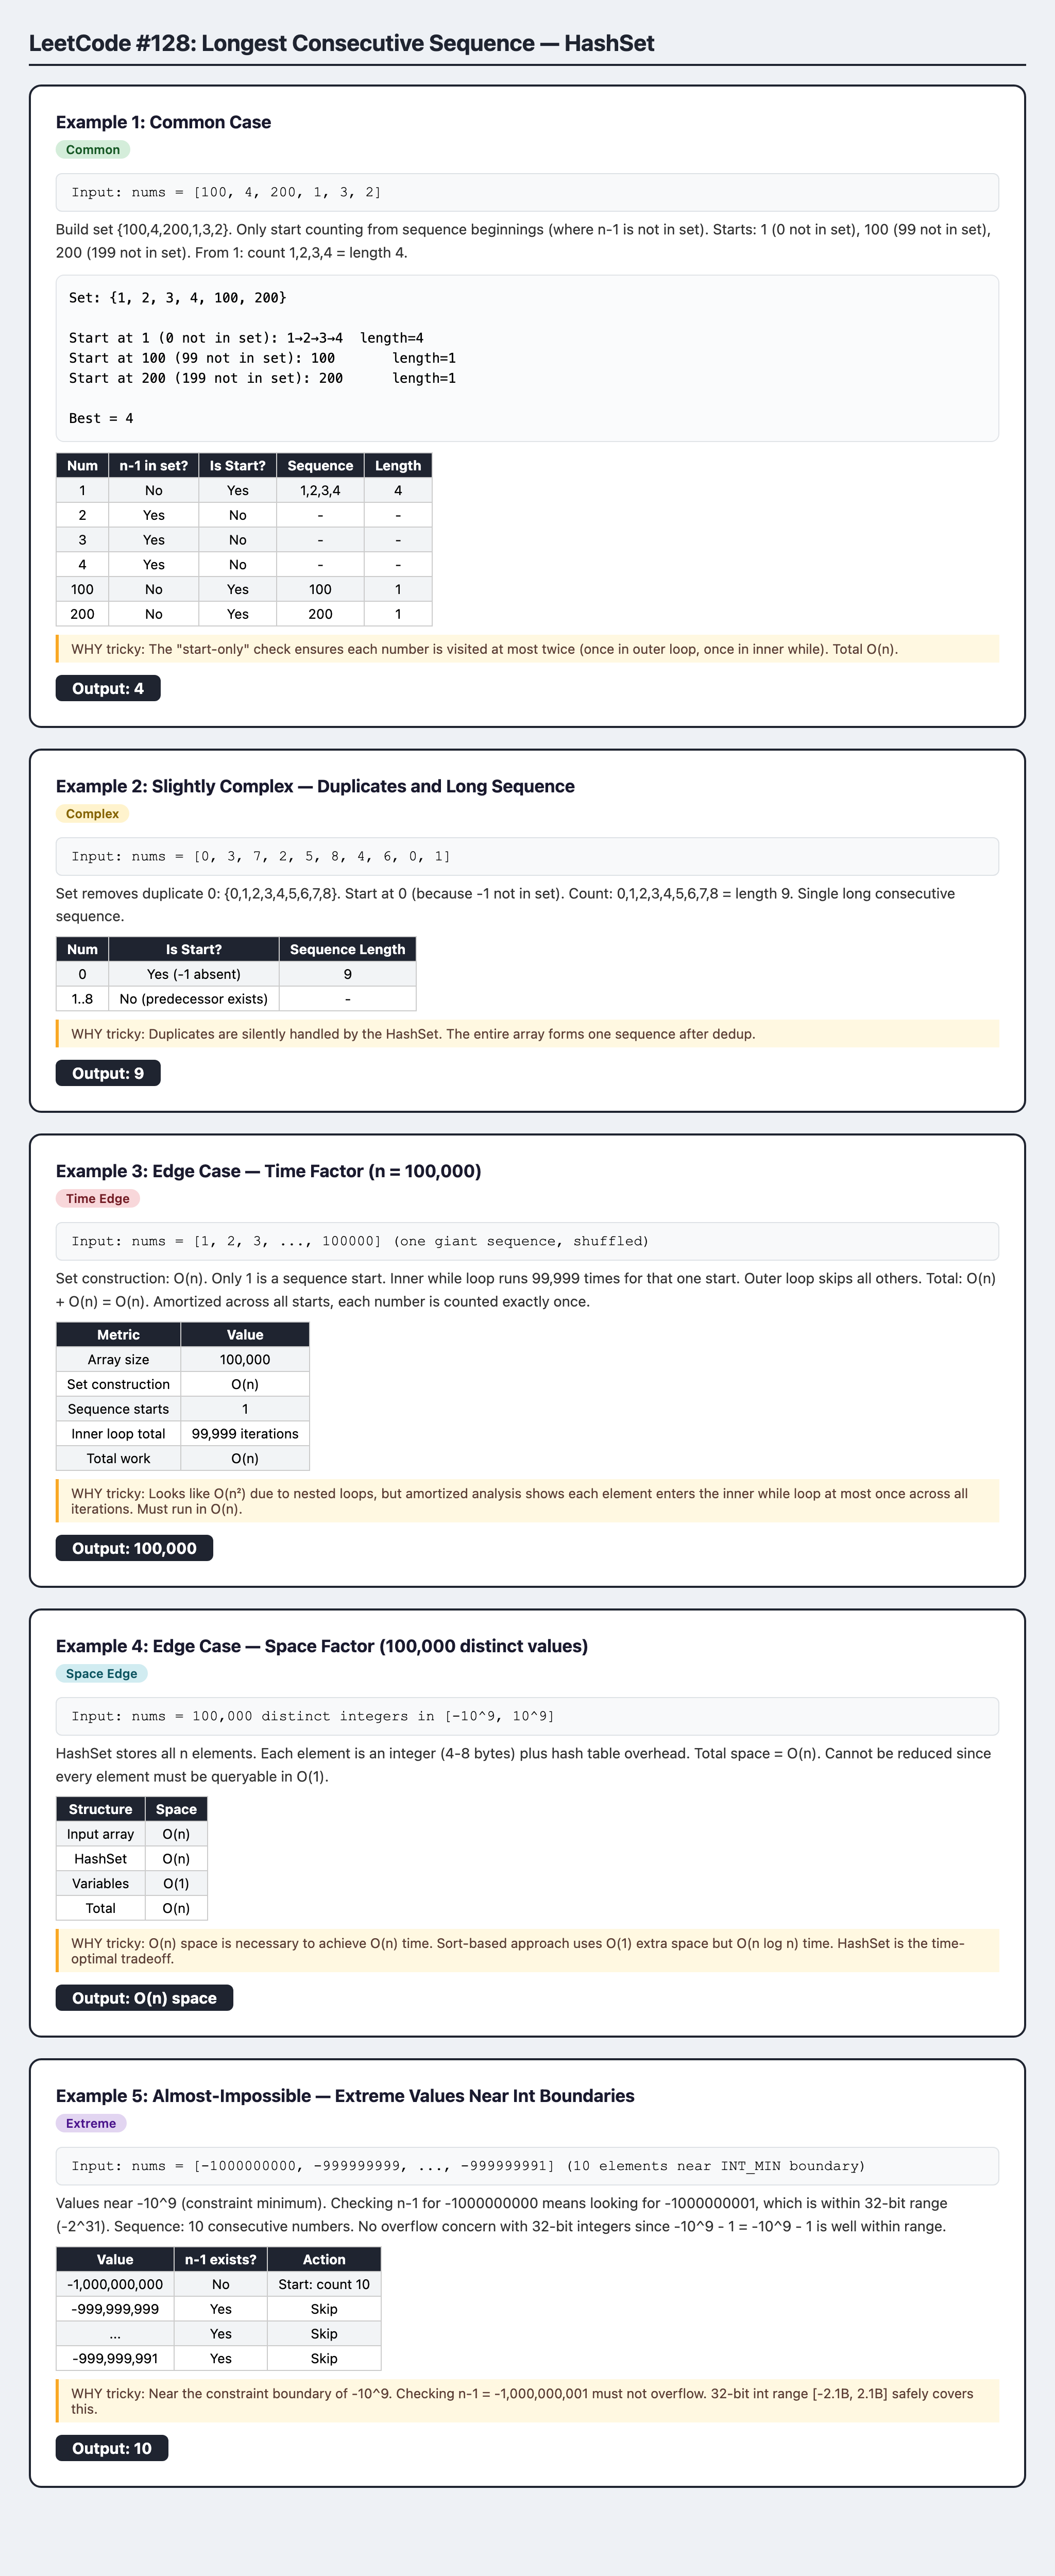